In [18]:
import os
import glob
import tiktoken
import numpy as np
import config

from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import DirectoryLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sklearn.manifold import TSNE
import plotly.graph_objects as go

In [2]:
os.environ['GOOGLE_API_KEY'] = config.GEMINI_API_KEY

In [3]:
MODEL_NAME = 'gemini-2.5-flash'
DB_NAME = 'insurellm_db'

In [4]:
# How many characters in all the documents?

knowledge_base_path = "knowledge-base/**/*.md"
files = glob.glob(knowledge_base_path, recursive=True)
print(f"Found {len(files)} files in the knowledge base")

entire_knowledge_base = ""

for file_path in files:
    with open(file_path, 'r', encoding='utf-8') as f:
        entire_knowledge_base += f.read()
        entire_knowledge_base += "\n\n"

print(f"Total characters in knowledge base: {len(entire_knowledge_base):,}")

Found 76 files in the knowledge base
Total characters in knowledge base: 304,434


In [5]:
import google.generativeai as genai

C:\Users\Rohan\AppData\Local\Temp\ipykernel_17492\613638648.py:1: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [6]:

# How many tokens in all the documents?
MODEL = 'gemini-2.5-flash'
model = genai.GenerativeModel(MODEL)
response = model.count_tokens(entire_knowledge_base)
token_count = response.total_tokens
print(f"Total tokens for {MODEL}: {token_count:,}")

Total tokens for gemini-2.5-flash: 68,696


In [7]:
glob.glob("knowledge-base/*")

['knowledge-base\\company',
 'knowledge-base\\contracts',
 'knowledge-base\\employees',
 'knowledge-base\\products']

In [8]:
# Load in everything in the knowledgebase using LangChain's loaders

folders = glob.glob("knowledge-base/*")

documents = []
for folder in folders:
    doc_type = os.path.basename(folder)
    loader = DirectoryLoader(folder, glob="**/*.md", loader_cls=TextLoader, loader_kwargs={'encoding': 'utf-8'})
    folder_docs = loader.load()
    for doc in folder_docs:
        doc.metadata["doc_type"] = doc_type
        documents.append(doc)

print(f"Loaded {len(documents)} documents")

Loaded 76 documents


In [9]:
type(documents[1])

langchain_core.documents.base.Document

In [10]:
documents[10]

Document(metadata={'source': 'knowledge-base\\contracts\\Contract with Continental Commercial Group for Bizllm.md', 'doc_type': 'contracts'}, page_content="# Contract with Continental Commercial Group for Bizllm\n\n**Contract Date:** April 12, 2025\n**Contract Number:** BZ-2025-E-0147\n**Parties:**\n- Insurellm, Inc.\n- Continental Commercial Group, Inc.\n\n---\n\n## Terms\n\n1. **Coverage:** Insurellm agrees to provide Continental Commercial Group with comprehensive access to the Bizllm Enterprise platform, including white-label capabilities, dedicated infrastructure, and full API access for commercial insurance operations across all 50 US states.\n\n2. **Duration:** This agreement is effective for a period of 36 months from the contract date, with provisions for early renewal discussions at the 24-month mark.\n\n3. **Payment:** Continental Commercial Group shall pay custom Enterprise pricing of $42,000 per month for the first 12 months, with pricing review and adjustment for years 2-

In [11]:
# Divide into chunks using the RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = text_splitter.split_documents(documents)

print(f"Divided into {len(chunks)} chunks")
print(f"First chunk:\n\n{chunks[0]}")

Divided into 413 chunks
First chunk:

page_content='# About Insurellm

Insurellm was founded by Avery Lancaster in 2015 as an insurance tech startup designed to disrupt an industry in need of innovative products. Its first product was Markellm, the marketplace connecting consumers with insurance providers.

The company experienced rapid growth in its first five years, expanding its product portfolio to include Carllm (auto insurance portal), Homellm (home insurance portal), and Rellm (enterprise reinsurance platform). By 2020, Insurellm had reached a peak of 200 employees with 12 offices across the US.' metadata={'source': 'knowledge-base\\company\\about.md', 'doc_type': 'company'}


In [12]:
chunks[100]

Document(metadata={'source': 'knowledge-base\\contracts\\Contract with GlobalRe Partners for Rellm.md', 'doc_type': 'contracts'}, page_content='13. **Climate Risk Analytics:** Forward-looking climate modeling:\n    - IPCC climate scenario analysis (RCP 2.6, 4.5, 8.5)\n    - Transition risk assessment\n    - Physical risk modeling for perils (hurricane, wildfire, flood, drought)\n    - Sea level rise impact analysis\n    - Temperature trend incorporation\n    - Climate-adjusted pricing recommendations\n    - Stranded asset identification\n    - Green reinsurance opportunities\n\n---\n\n## Support\n\nInsurellm commits to comprehensive Enterprise-level support for GlobalRe Partners:\n\n1. **Dedicated Success Team:**\n   - Executive sponsor (CEO-level) with quarterly strategic reviews\n   - Dedicated Senior Vice President of Customer Success with bi-weekly engagement\n   - Technical Account Manager for platform optimization\n   - Solutions Architect team (2 FTE) for strategic initiatives\n

### Lets make vectors and store it in chromaDB

In [13]:
# Pick an embedding model
from langchain_google_genai import GoogleGenerativeAIEmbeddings

# embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
#embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")
if os.path.exists(DB_NAME):
    Chroma(persist_directory=DB_NAME, embedding_function=embeddings).delete_collection()

vectorstore = Chroma.from_documents(documents=chunks, embedding=embeddings, persist_directory=DB_NAME)
print(f"Vectorstore created with {vectorstore._collection.count()} documents")

Vectorstore created with 413 documents


In [14]:
# Let's investigate the vectors

collection = vectorstore._collection
count = collection.count()

sample_embedding = collection.get(limit=1, include=["embeddings"])["embeddings"][0]
print(sample_embedding)
dimensions = len(sample_embedding)
print(f"There are {count:,} vectors with {dimensions:,} dimensions in the vector store")

[-0.0145931   0.03629373  0.0110112  ...  0.00975338  0.01002639
 -0.01620367]
There are 413 vectors with 3,072 dimensions in the vector store


### Visualize

In [15]:
# Prework

result = collection.get(include=['embeddings', 'documents', 'metadatas'])
vectors = np.array(result['embeddings'])
documents = result['documents']
metadatas = result['metadatas']
doc_types = [metadata['doc_type'] for metadata in metadatas]
colors = [['blue', 'green', 'red', 'orange'][['products', 'employees', 'contracts', 'company'].index(t)] for t in doc_types]

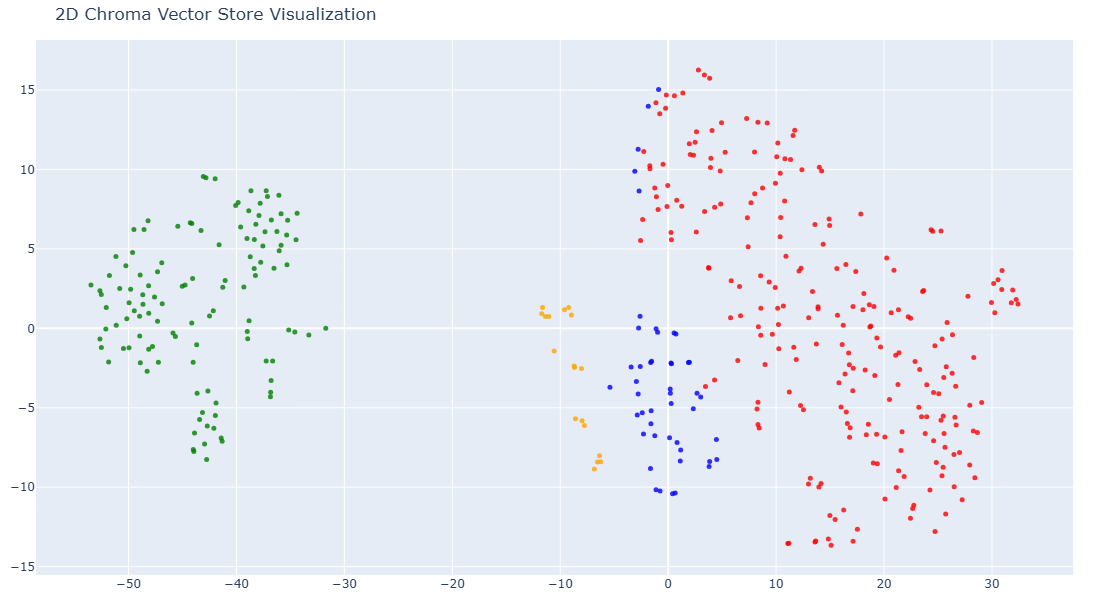

In [16]:
# We humans find it easier to visalize things in 2D!
# Reduce the dimensionality of the vectors to 2D using t-SNE
# (t-distributed stochastic neighbor embedding)

tsne = TSNE(n_components=2, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

# Create the 2D scatter plot
fig = go.Figure(data=[go.Scatter(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    mode='markers',
    marker=dict(size=5, color=colors, opacity=0.8),
    text=[f"Type: {t}<br>Text: {d[:100]}..." for t, d in zip(doc_types, documents)],
    hoverinfo='text'
)])

fig.update_layout(title='2D Chroma Vector Store Visualization',
    scene=dict(xaxis_title='x',yaxis_title='y'),
    width=800,
    height=600,
    margin=dict(r=20, b=10, l=10, t=40)
)

fig.show()

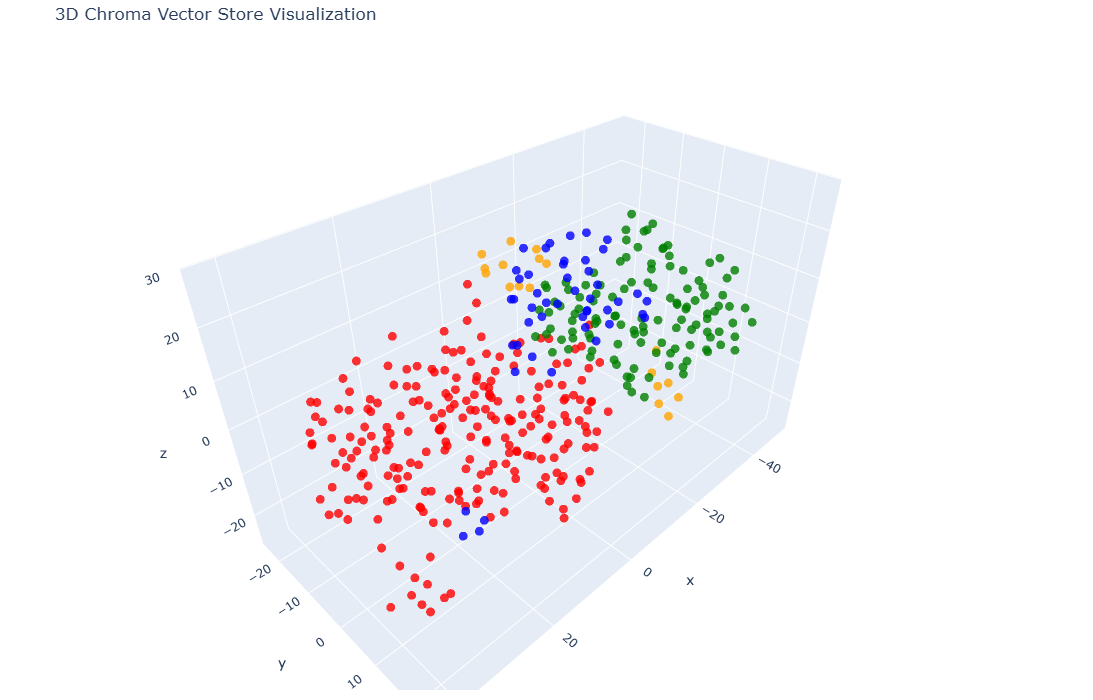

In [17]:
# Let's try 3D!

tsne = TSNE(n_components=3, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

# Create the 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    z=reduced_vectors[:, 2],
    mode='markers',
    marker=dict(size=5, color=colors, opacity=0.8),
    text=[f"Type: {t}<br>Text: {d[:100]}..." for t, d in zip(doc_types, documents)],
    hoverinfo='text'
)])

fig.update_layout(
    title='3D Chroma Vector Store Visualization',
    scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='z'),
    width=900,
    height=700,
    margin=dict(r=10, b=10, l=10, t=40)
)

fig.show()